# LIBROSA

In this problem, we are going to use librosa. It is a python library which is used to preprocess the audio and speech data. The main purpose of librosa is to process the audio and convert it into features for modeling.

## Import Modules

In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio
import warnings
import zipfile
warnings.filterwarnings('ignore')

## Load the Dataset

In [2]:
!pip install kaggle

In [3]:
os.environ['KAGGLE_USERNAME'] = "abdulrehman1302"
os.environ['KAGGLE_KEY'] = "KGAT_03e294475347e3d3bea1fab2be412962"
print(os.environ['KAGGLE_USERNAME'])
print(os.environ['KAGGLE_KEY'])

abdulrehman1302
KGAT_03e294475347e3d3bea1fab2be412962


In [4]:
!kaggle datasets download -d ejlok1/toronto-emotional-speech-set-tess

Dataset URL: https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 428M/428M [00:04<00:00, 100MB/s]



In [5]:
zip_ref=zipfile.ZipFile('/content/toronto-emotional-speech-set-tess.zip')
zip_ref.extractall('/content')
zip_ref.close()

In [6]:
import os

paths = []
labels = []

DATASET_PATH = "/content/tess toronto emotional speech set data/TESS Toronto emotional speech set data/"

for dirname, _, filenames in os.walk(DATASET_PATH):
    for filename in filenames:
        if filename.endswith(".wav"):
            full_path = os.path.join(dirname, filename)
            paths.append(full_path)

            # Try filename label
            if "_" in filename:
                label = filename.split('_')[-1].split('.')[0]
            else:
                # fallback: folder name
                label = os.path.basename(dirname)

            labels.append(label.lower())

print("Dataset Loaded")
print("Total files:", len(paths))

Dataset Loaded
Total files: 2800


In [7]:
len(paths)

2800

In [8]:
paths[:5]

['/content/tess toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_pleasant_surprised/YAF_which_ps.wav',
 '/content/tess toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_pleasant_surprised/YAF_said_ps.wav',
 '/content/tess toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_pleasant_surprised/YAF_mob_ps.wav',
 '/content/tess toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_pleasant_surprised/YAF_mouse_ps.wav',
 '/content/tess toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_pleasant_surprised/YAF_bean_ps.wav']

In [9]:
labels[:5]

['ps', 'ps', 'ps', 'ps', 'ps']

In [10]:
## Create a dataframe
df = pd.DataFrame()
df['speech'] = paths
df['label'] = labels
df.head()

,speech,label
0,/content/tess toronto emotional speech set dat...,ps
1,/content/tess toronto emotional speech set dat...,ps
2,/content/tess toronto emotional speech set dat...,ps
3,/content/tess toronto emotional speech set dat...,ps
4,/content/tess toronto emotional speech set dat...,ps


In [11]:
df['label'].value_counts()

,count
label,
ps,400
happy,400
sad,400
fear,400
disgust,400
angry,400
neutral,400


## Exploratory Data Analysis

<Axes: xlabel='label', ylabel='count'>

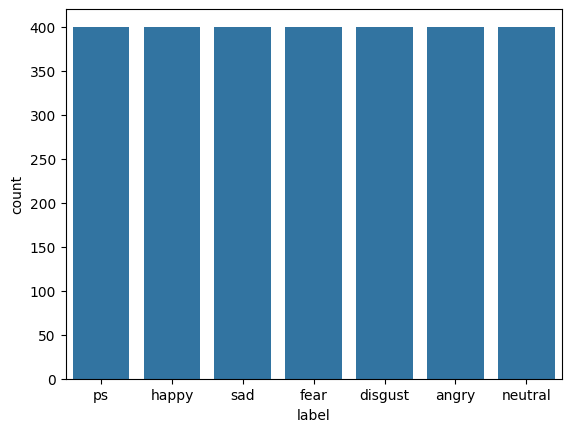

In [12]:
sns.countplot(data=df, x='label')

In [13]:
def waveplot(data, sr, emotion):
    plt.figure(figsize=(10,4))
    plt.title(emotion, size=20)
    librosa.display.waveshow(data, sr=sr)
    plt.show()

def spectogram(data, sr, emotion):
    x = librosa.stft(data)
    xdb = librosa.amplitude_to_db(abs(x))
    plt.figure(figsize=(11,4))
    plt.title(emotion, size=20)
    librosa.display.specshow(xdb, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar()

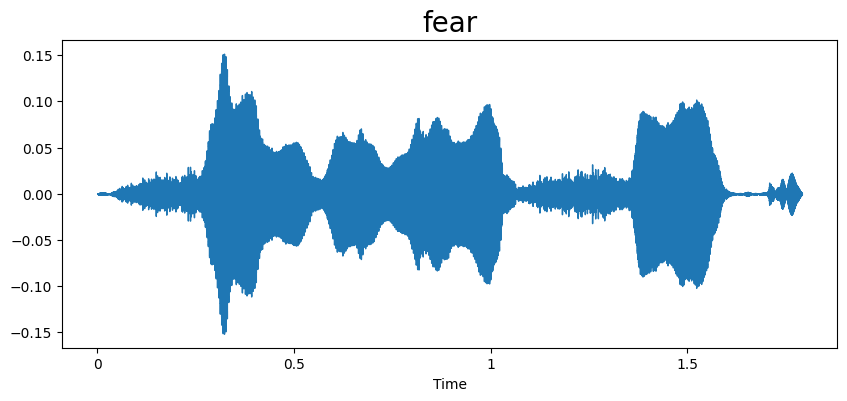

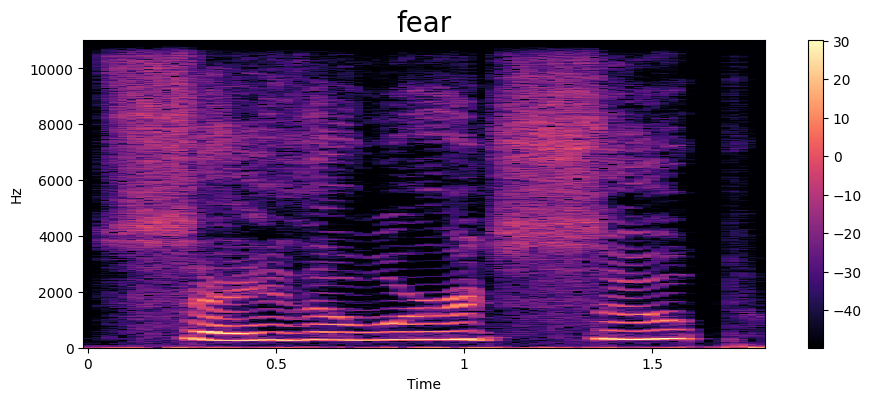

In [14]:
emotion = 'fear'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

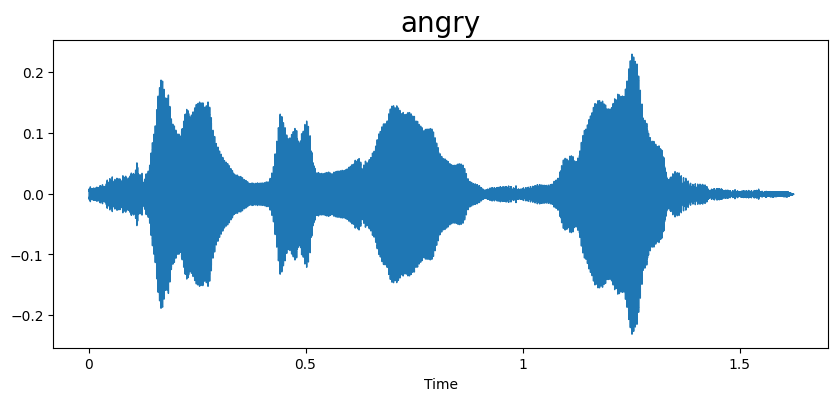

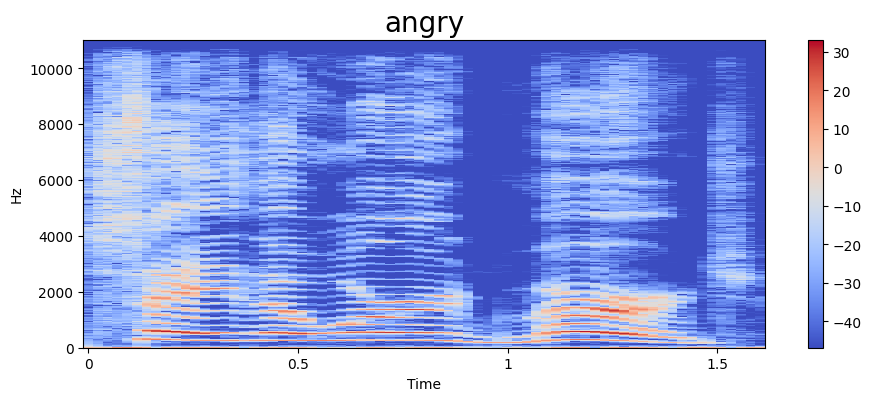

In [15]:
emotion = 'angry'
path = np.array(df['speech'][df['label']==emotion])[1]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

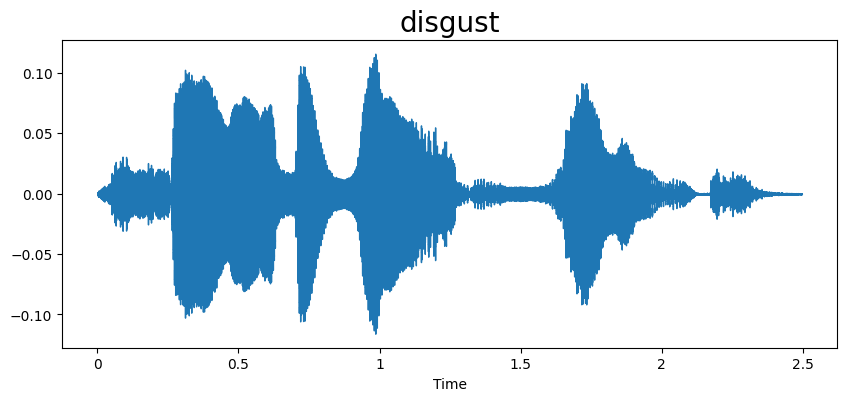

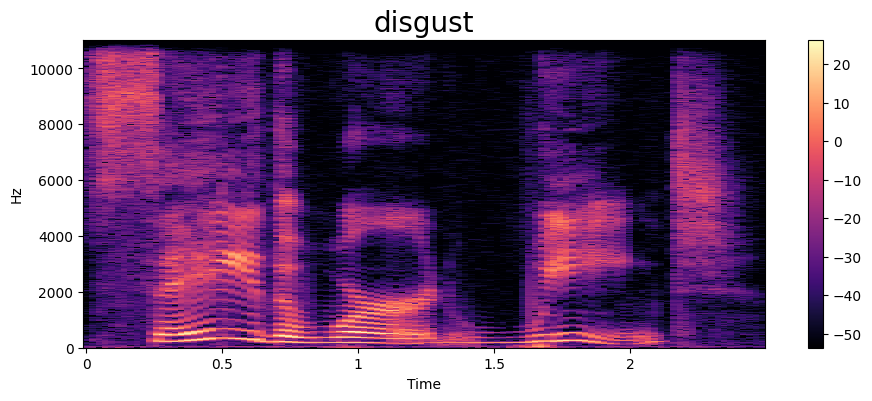

In [16]:
emotion = 'disgust'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

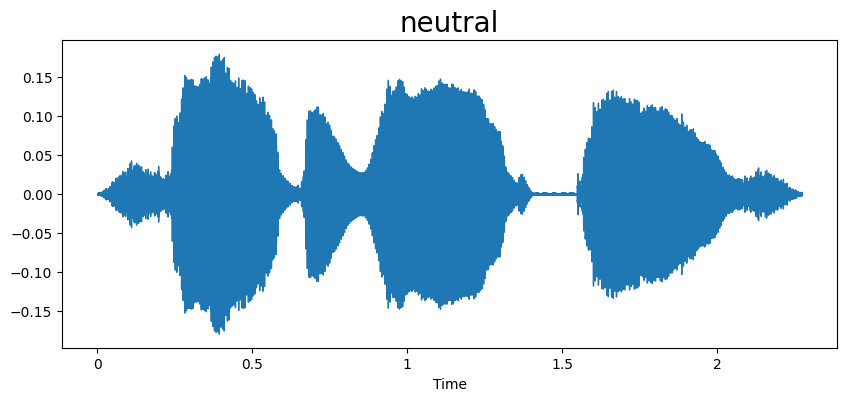

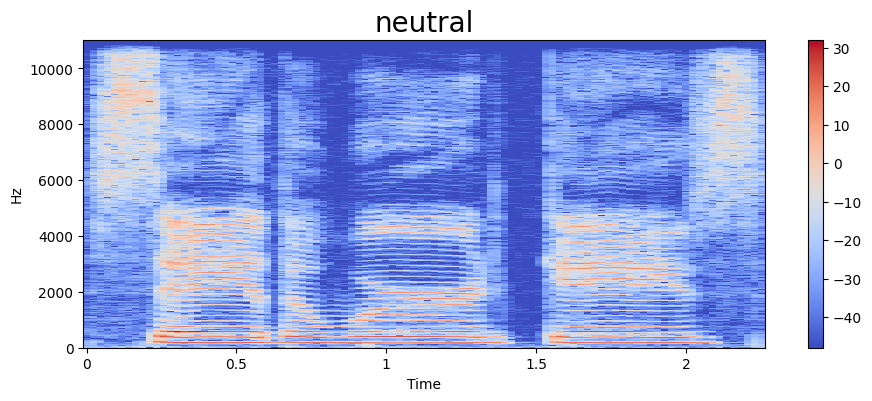

In [17]:
emotion = 'neutral'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

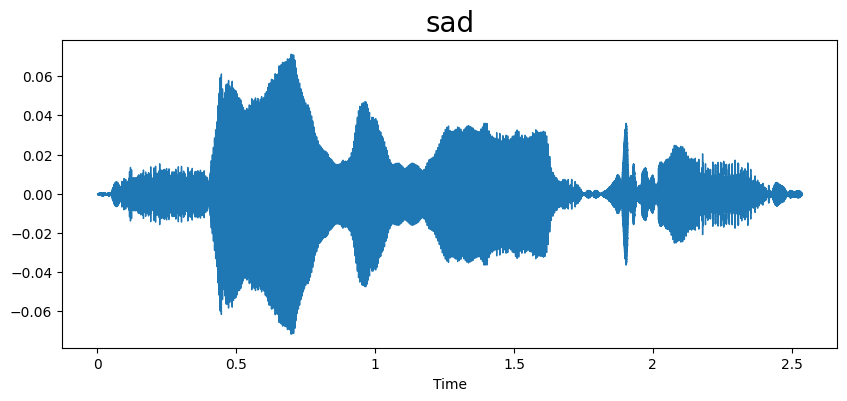

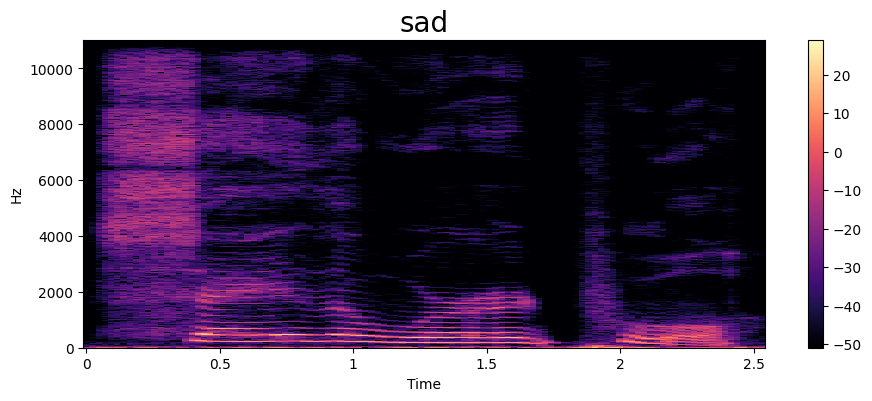

In [18]:
emotion = 'sad'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

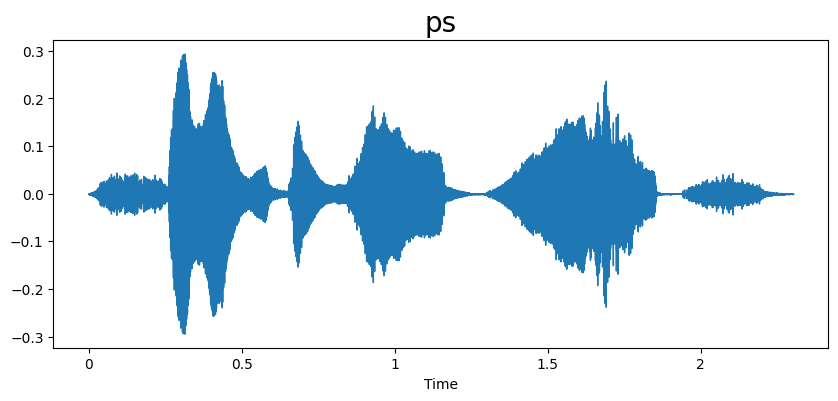

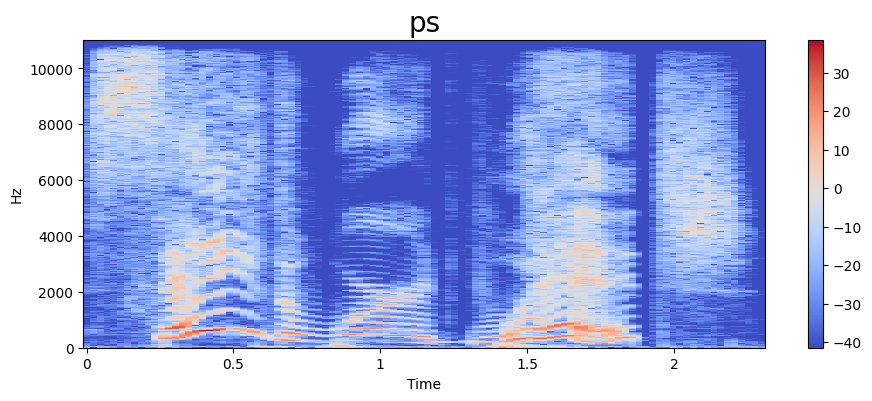

In [19]:
emotion = 'ps'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

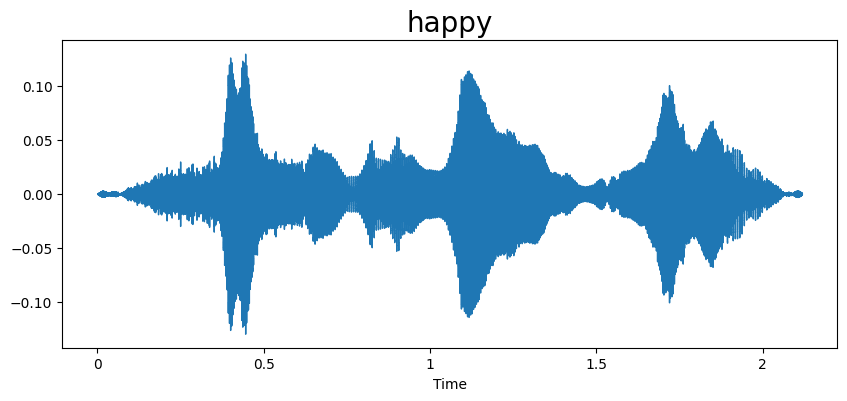

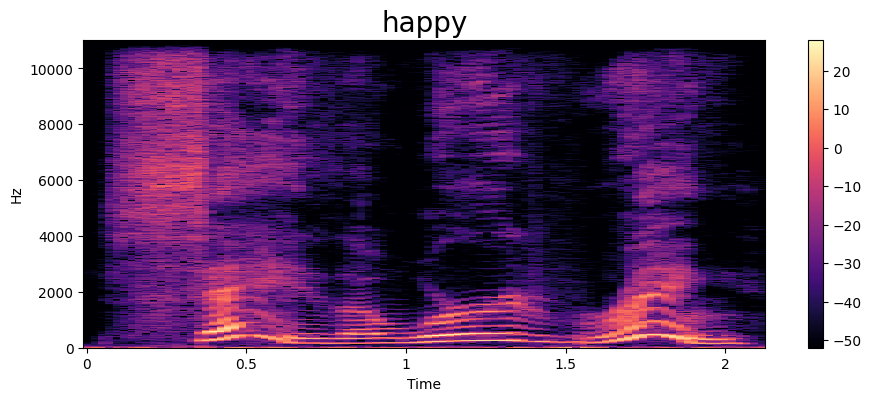

In [20]:
emotion = 'happy'
path = np.array(df['speech'][df['label']==emotion])[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

## Feature Extraction

In [21]:
def extract_mfcc(filename):
    y, sr = librosa.load(filename, duration=3, offset=0.5)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mfcc = mfcc.T   # (time_steps, 40)
    return mfcc

In [22]:
extract_mfcc(df['speech'][0])

array([[-3.1439984e+02,  4.0531891e+01,  2.6318613e-01, ...,
         8.4999409e+00, -1.2835009e+01,  3.5168095e+00],
       [-3.0992944e+02,  1.0789125e+01, -5.0979509e+00, ...,
         6.3646550e+00, -9.9725304e+00, -2.5412736e+00],
       [-3.2194418e+02, -9.5677261e+00, -1.0361108e+00, ...,
         5.9057980e+00, -1.0587493e+00, -1.3227088e+00],
       ...,
       [-5.2870941e+02,  6.7224109e-01, -2.4687805e+01, ...,
         3.8782411e+00,  2.4700785e+00,  1.5710306e+00],
       [-5.7044647e+02,  2.4069391e+01, -1.6124056e+01, ...,
         3.0565314e+00, -1.0489758e+00,  3.7207088e+00],
       [-6.2019202e+02,  3.2694939e+01,  4.1018338e+00, ...,
         1.7496808e+00, -1.2435820e+00,  3.3549287e+00]], dtype=float32)

In [23]:
x_mfcc = df['speech'].apply(lambda x: extract_mfcc(x))

In [24]:
x_mfcc

,speech
0,"[[-314.39984, 40.53189, 0.26318613, 15.870516,..."
1,"[[-298.31384, 35.35698, -10.122568, -12.423413..."
2,"[[-373.37628, 54.674942, -8.953474, -4.0183015..."
3,"[[-315.3589, 24.122795, -2.8949692, -1.1198502..."
4,"[[-288.21487, 67.841995, -16.490545, 19.625721..."
...,...
2795,"[[-424.88123, 118.32527, 19.568161, 32.222336,..."
2796,"[[-430.25742, 126.82578, 19.518959, 47.3072, 4..."
2797,"[[-394.5166, 120.04816, 10.960973, 27.260014, ..."
2798,"[[-330.0855, 107.35567, 17.333868, 19.102112, ..."


In [25]:
x_mfcc[0]

array([[-3.1439984e+02,  4.0531891e+01,  2.6318613e-01, ...,
         8.4999409e+00, -1.2835009e+01,  3.5168095e+00],
       [-3.0992944e+02,  1.0789125e+01, -5.0979509e+00, ...,
         6.3646550e+00, -9.9725304e+00, -2.5412736e+00],
       [-3.2194418e+02, -9.5677261e+00, -1.0361108e+00, ...,
         5.9057980e+00, -1.0587493e+00, -1.3227088e+00],
       ...,
       [-5.2870941e+02,  6.7224109e-01, -2.4687805e+01, ...,
         3.8782411e+00,  2.4700785e+00,  1.5710306e+00],
       [-5.7044647e+02,  2.4069391e+01, -1.6124056e+01, ...,
         3.0565314e+00, -1.0489758e+00,  3.7207088e+00],
       [-6.2019202e+02,  3.2694939e+01,  4.1018338e+00, ...,
         1.7496808e+00, -1.2435820e+00,  3.3549287e+00]], dtype=float32)

In [26]:
#diffrent shapes
x_mfcc[1].shape

(57, 40)

# Padding

In [27]:
from keras.preprocessing.sequence import pad_sequences

In [28]:
# applied padding for set the shape of array same
x_mfcc = pad_sequences(x_mfcc, padding='post', dtype='float32')

In [29]:
x_mfcc

array([[[-3.1439984e+02,  4.0531891e+01,  2.6318613e-01, ...,
          8.4999409e+00, -1.2835009e+01,  3.5168095e+00],
        [-3.0992944e+02,  1.0789125e+01, -5.0979509e+00, ...,
          6.3646550e+00, -9.9725304e+00, -2.5412736e+00],
        [-3.2194418e+02, -9.5677261e+00, -1.0361108e+00, ...,
          5.9057980e+00, -1.0587493e+00, -1.3227088e+00],
        ...,
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

       [[-2.9831384e+02,  3.5356979e+01, -1.0122568e+01, ...,
          2.2279477e+00, -6.6224113e+00,  7.9275432e+00],
        [-3.0860309e+02,  3.3517914e+01, -1.8751354e+01, ...,
          7.2916980e+00, -4.6124477e+00,  7.9890432e+00],
        [-3.6962384e+02, 

In [30]:
x_mfcc.shape

(2800, 108, 40)

In [31]:
# first converted from pandas series to python list and then numpy array
x = [x for x in x_mfcc]
x = np.array(x)
x.shape

(2800, 108, 40)

In [32]:
## input split
x= np.expand_dims(x, -1)
x.shape

(2800, 108, 40, 1)

In [33]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
y = enc.fit_transform(df[['label']])

In [34]:
y = y.toarray()

In [35]:
y.shape

(2800, 7)

# Create RNN Model

In [36]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [37]:

model = Sequential([

    # RNN layer
    SimpleRNN(64, return_sequences=True, input_shape=(x.shape[1], x.shape[2])),
    BatchNormalization(),
    Dropout(0.4),

    # RNN layer
    SimpleRNN(32),
    BatchNormalization(),
    Dropout(0.4),

    Dense(16, activation='relu'),
    Dropout(0.3),

    # Output layer
    Dense(7, activation='softmax')
])

In [38]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_8 (SimpleRNN)        │ (None, 108, 64)        │         6,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 108, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 108, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_9 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,855 (42.40 KB)

 Trainable params: 10,663 (41.65 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
history = model.fit(
    x, y,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    # callbacks=[early_stop, lr_reduce]
)

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.1777 - loss: 2.2926 - val_accuracy: 0.0036 - val_loss: 2.3645
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.2188 - loss: 2.0161 - val_accuracy: 0.0000e+00 - val_loss: 2.6771
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.2473 - loss: 1.9277 - val_accuracy: 0.2107 - val_loss: 2.2983
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.2821 - loss: 1.7709 - val_accuracy: 0.1071 - val_loss: 2.5767
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.3174 - loss: 1.6958 - val_accuracy: 0.1054 - val_loss: 2.6449
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.3451 - loss: 1.6288 - val_accuracy: 0.0036 - val_loss: 2.7032
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.2897 - loss: 1.7251 - val_accuracy: 0.0000e+00 - val_loss: 4.0556
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.1714 - loss: 1.9952 - val_accuracy: 0.

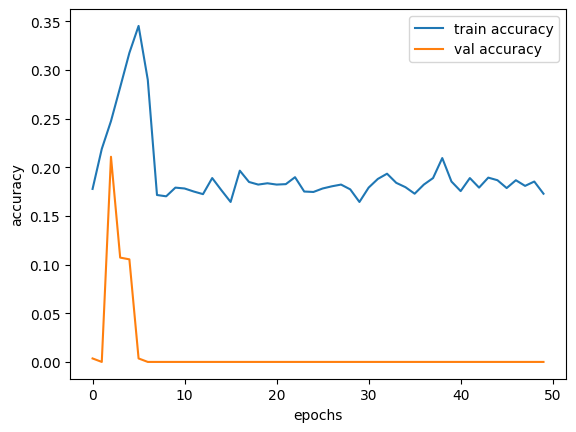

In [ ]:
epochs = list(range(50))
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, label='train accuracy')
plt.plot(epochs, val_acc, label='val accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

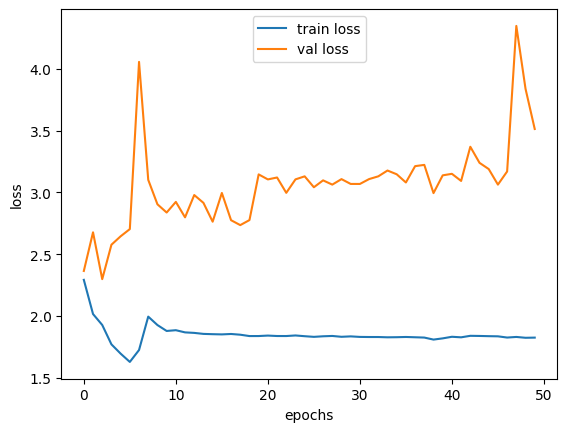

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs, loss, label='train loss')
plt.plot(epochs, val_loss, label='val loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

## Create the LSTM Model

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(x.shape[1], x.shape[2])),
    Dropout(0.3),

    # Dense(32, activation='relu'),
    # Dropout(0.3),

    Dense(16, activation='relu'),
    Dropout(0.3),

    Dense(7, activation='softmax')
])


In [ ]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [ ]:
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 64)             │        26,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,039 (109.53 KB)

 Trainable params: 28,039 (109.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(x, y, validation_split=0.2, epochs=50, batch_size=64)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.2576 - loss: 1.7877 - val_accuracy: 0.0000e+00 - val_loss: 2.2583
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.3973 - loss: 1.4788 - val_accuracy: 0.0000e+00 - val_loss: 2.9938
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.5031 - loss: 1.1652 - val_accuracy: 0.0000e+00 - val_loss: 3.2462
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.5862 - loss: 0.9630 - val_accuracy: 0.0000e+00 - val_loss: 3.3752
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.6219 - loss: 0.8376 - val_accuracy: 0.0000e+00 - val_loss: 4.1425
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.6696 - loss: 0.7335 - val_accuracy: 0.0018 - val_loss: 4.3167
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.7196 - loss: 0.6117 - val_accuracy: 0.0018 - val_loss: 4.3932
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.7411 - loss: 0.5713 - val

In [ ]:
# best val accuracy: 72.32
# use checkpoint to save the best val accuracy model
# adjust learning rate for slow convergence

## Plot the results

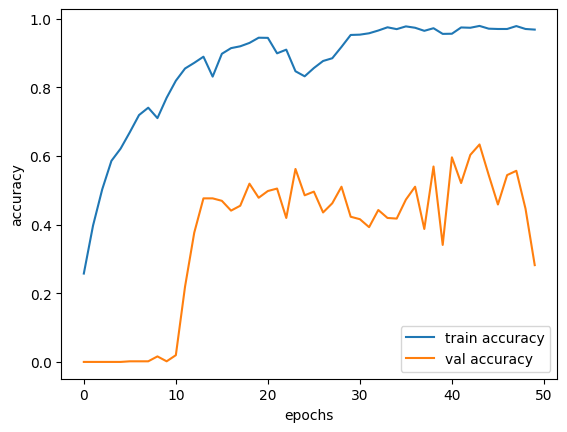

In [ ]:
epochs = list(range(50))
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, label='train accuracy')
plt.plot(epochs, val_acc, label='val accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

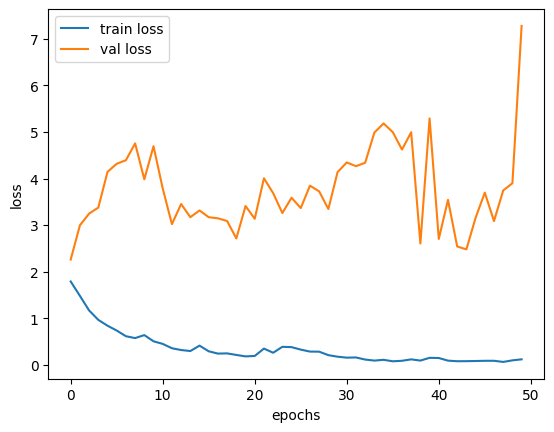

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs, loss, label='train loss')
plt.plot(epochs, val_loss, label='val loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()